## Ejercicio 2.
Utilice la red de Hopfield como memoria asociativa para los dı́gitos de 0 a 9. Diseñe una interfaz para ingresar los dı́gitos manualmente de forma que la red recupere las memorias fundamentales.

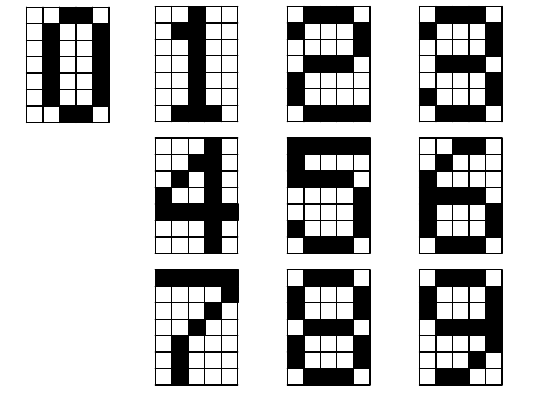



Forma de la matriz de entrada X_digitos: (10, 35)


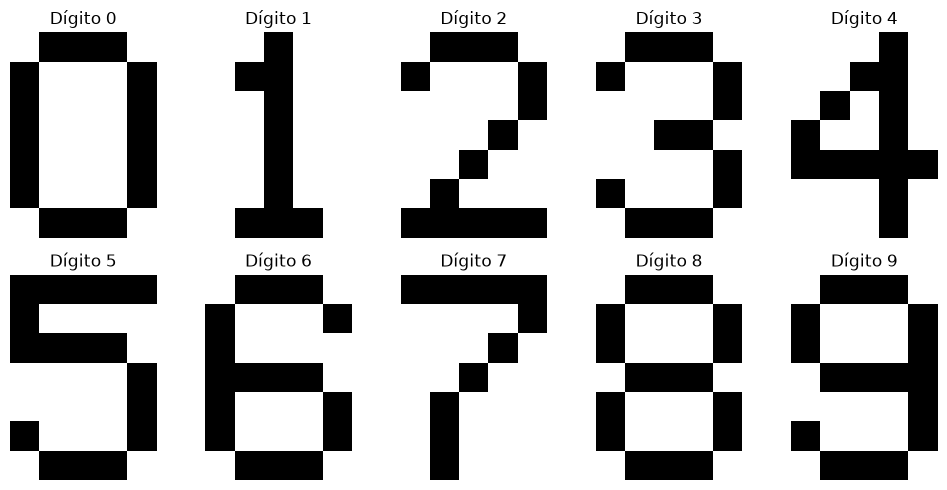

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Matrices de 5x7 para los dígitos del 0 al 9
# 1 = Negro, -1 = Blanco

d0 = np.array([
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1]
])

d1 = np.array([
    [-1, -1,  1, -1, -1],
    [-1,  1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1,  1,  1,  1, -1]
])

d2 = np.array([
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [-1, -1, -1, -1,  1],
    [-1, -1, -1,  1, -1],
    [-1, -1,  1, -1, -1],
    [-1,  1, -1, -1, -1],
    [ 1,  1,  1,  1,  1]
])

d3 = np.array([
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [-1, -1, -1, -1,  1],
    [-1, -1,  1,  1, -1],
    [-1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1]
])

d4 = np.array([
    [-1, -1, -1,  1, -1],
    [-1, -1,  1,  1, -1],
    [-1,  1, -1,  1, -1],
    [ 1, -1, -1,  1, -1],
    [ 1,  1,  1,  1,  1],
    [-1, -1, -1,  1, -1],
    [-1, -1, -1,  1, -1]
])

d5 = np.array([
    [ 1,  1,  1,  1,  1],
    [ 1, -1, -1, -1, -1],
    [ 1,  1,  1,  1, -1],
    [-1, -1, -1, -1,  1],
    [-1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1]
])

d6 = np.array([
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1, -1],
    [ 1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1]
])

d7 = np.array([
    [ 1,  1,  1,  1,  1],
    [-1, -1, -1, -1,  1],
    [-1, -1, -1,  1, -1],
    [-1, -1,  1, -1, -1],
    [-1,  1, -1, -1, -1],
    [-1,  1, -1, -1, -1],
    [-1,  1, -1, -1, -1]
])

d8 = np.array([
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1]
])

d9 = np.array([
    [-1,  1,  1,  1, -1],
    [ 1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1,  1],
    [-1, -1, -1, -1,  1],
    [ 1, -1, -1, -1,  1],
    [-1,  1,  1,  1, -1]
])


digitos = [d0, d1, d2, d3, d4, d5, d6, d7, d8, d9]
X_digitos = np.array([d.flatten() for d in digitos])

print(f"Forma de la matriz de entrada X_digitos: {X_digitos.shape}")

# Visualización rápida para comprobar que se cargaron bien
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digitos[i], cmap='Greys')
    ax.axis('off')
    ax.set_title(f'Dígito {i}')
plt.tight_layout()
plt.show()

In [6]:
## Forma vectorial para calcular los pesos:
def entrenar_hopfield(X_patrones):
    # X_patrones tiene forma (M, N) con valores en {-1, +1}
    M, N = X_patrones.shape
    
    # Producto externo vectorial acumulado
    W = (1.0 / N) * np.dot(X_patrones.T, X_patrones)
    
    # Imponer diagonal nula (sin autoconexiones)
    np.fill_diagonal(W, 0.0)
    
    return W

## Forma de recuperación asíncrona:
def recuperar_memoria_asincrona(y_ruidoso, W, max_iter=500):
    y = y_ruidoso.copy()
    N = len(y)
    
    for iteracion in range(max_iter):
        y_previo = y.copy()
        
        # Seleccionar orden aleatorio de neuronas a actualizar
        indices = np.random.permutation(N)
        
        for j in indices:
            # Campo local neto: sum(W_ji * y_i)
            campo_local = np.dot(W[j, :], y)
            
            # Regla de activación bipolar sgn
            if campo_local > 0:
                y[j] = 1
            elif campo_local < 0:
                y[j] = -1
            # Si campo_local == 0, y[j] no cambia
            
        # Verificar criterio de parada (punto fijo alcanzado)
        if np.array_equal(y, y_previo):
            print(f"Convergencia alcanzada en la iteración {iteracion + 1}.")
            break
            
    return y

def capacidad_max_almacenamiento(X_patrones):

    N = X_patrones.shape[1]

    return N / (2*np.log(N))


###  Entrenar la red:
# X_0 = X_digitos[[0, 3, 6, 7]]
## Dividir los patrones en 3:
W_0 = entrenar_hopfield(X_digitos[[1, 2, 6]])
W_1 = entrenar_hopfield(X_digitos[[0, 4, 7, 8]])
W_2 = entrenar_hopfield(X_digitos[[3, 5, 9]])
P_max = capacidad_max_almacenamiento(X_digitos)

print(f"Capacidad máxima de almacenamiento para la red: {P_max}\n")


Capacidad máxima de almacenamiento para la red: 4.922162246097747



### Consideraciones para este problema

AL intentar entrenar la red pasándole la matriz X_digitos completa (los 10 patrones a la vez), el crosstalk destruirá la red inmediatamente porque excede la capacidad al doble, y además números como el 8, 9, 0 y 6 comparten demasiados píxeles.

Para que la interfaz de recuperación funcione en este ejercicio, se puede entrenar la red con un máximo de 3 o 4 dígitos a la vez (por ejemplo: el 1, el 4 y el 7, que son ortogonales y muy distintos entre sí) usando slicing: W = entrenar_hopfield(X_digitos[[1, 4, 7]]).



Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1  1 -1 -1 -1  1  1 -1 -1 -1  1  1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


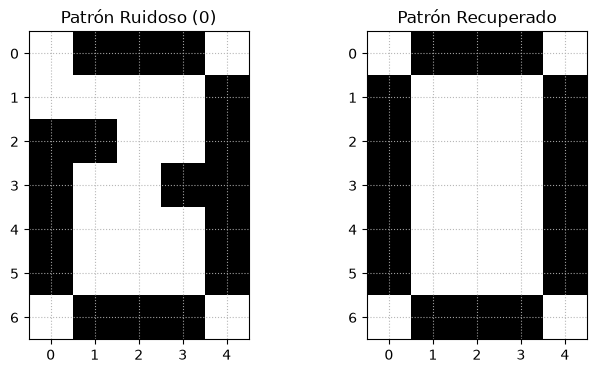

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1 -1  1 -1 -1 -1  1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1
 -1 -1 -1  1 -1 -1 -1  1  1  1 -1]


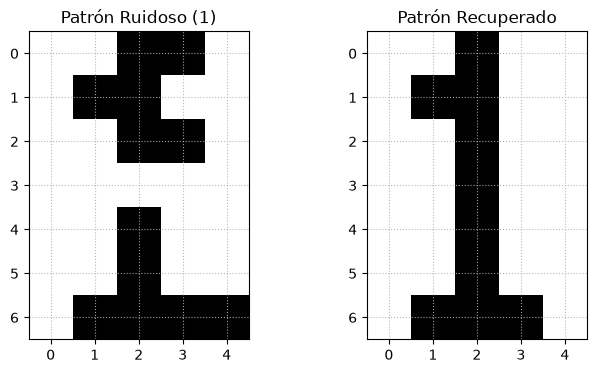

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1  1 -1
 -1 -1  1 -1 -1 -1  1  1  1  1  1]


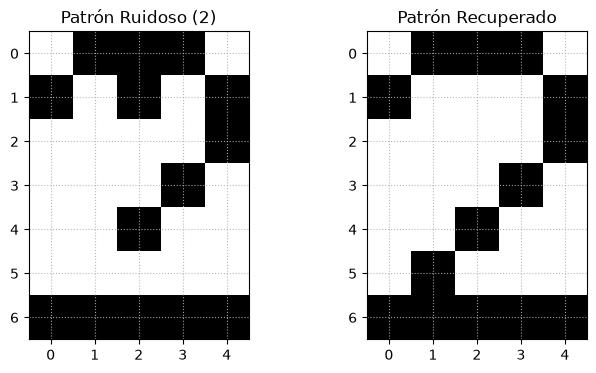

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1  1 -1 -1 -1  1 -1 -1  1  1  1 -1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


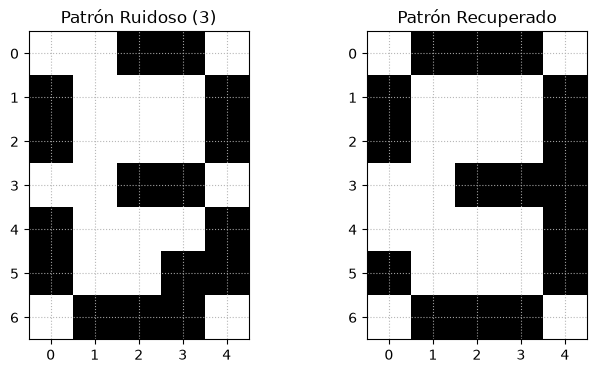

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1 -1 -1  1 -1 -1 -1  1  1 -1 -1  1 -1  1 -1  1 -1 -1  1 -1  1  1  1  1
  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1]


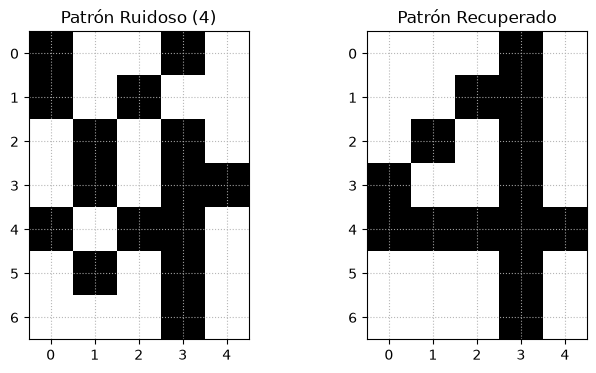

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[ 1  1  1  1  1  1 -1 -1 -1 -1  1  1  1  1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


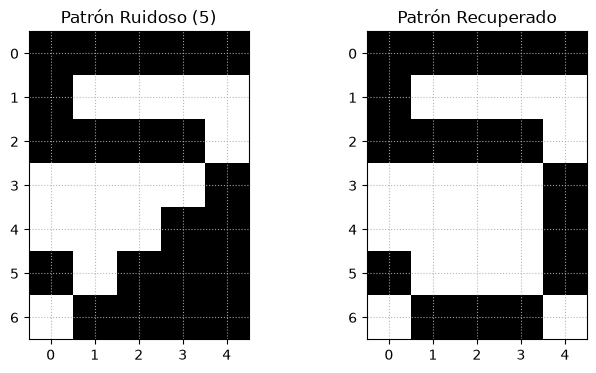

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1  1 -1 -1 -1 -1  1  1  1  1 -1  1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


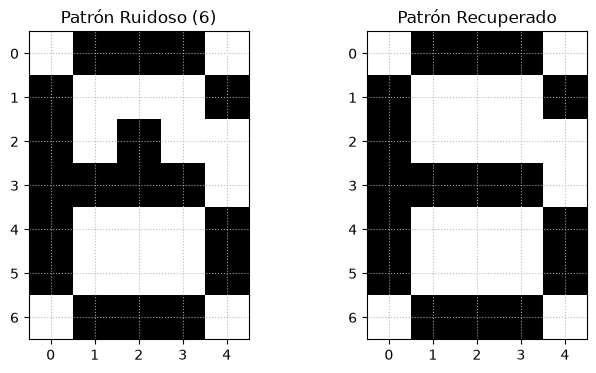

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[ 1  1  1  1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1  1 -1 -1
 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1]


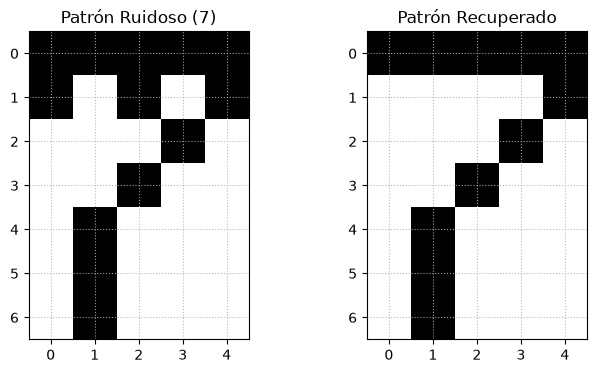

Convergencia alcanzada en la iteración 3.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1  1 -1 -1 -1  1 -1  1  1 -1  1  1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


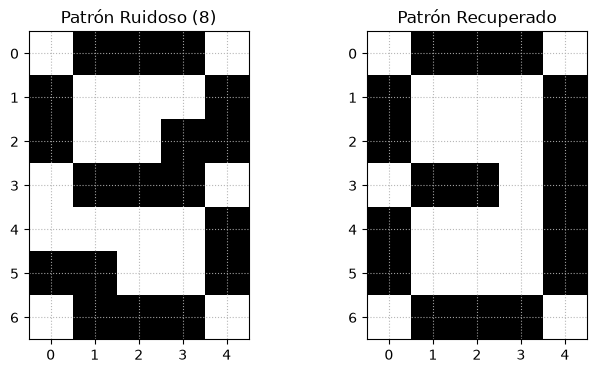

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1  1 -1 -1 -1  1 -1  1  1 -1  1  1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


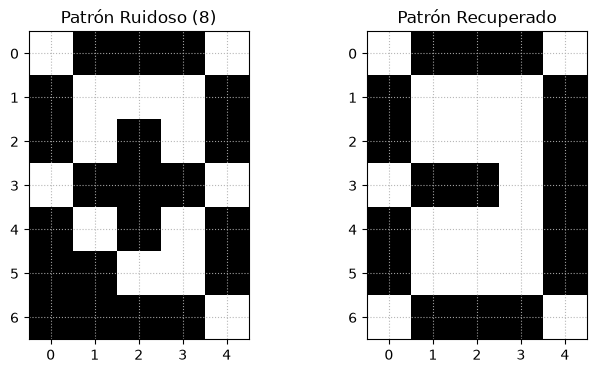

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1  1  1  1 -1  1 -1 -1 -1  1  1 -1 -1 -1  1 -1 -1  1  1  1 -1 -1 -1 -1
  1  1 -1 -1 -1  1 -1  1  1  1 -1]


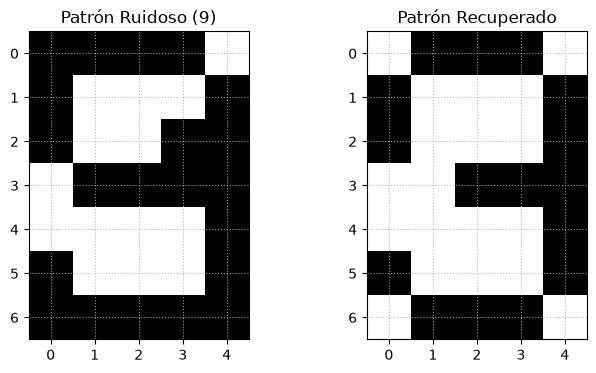

In [8]:

dig_user = input("Ingresar digito a recuperar (-1 para salir): ")

while dig_user != "-1":
    
    # Buscar el patrón original exacto que pidió el usuario
    idx = int(dig_user)
    patron_base = digitos[idx].copy()
    
    # Generar ruido: Invertir el 10% de los píxeles aleatoriamente
    probabilidad_ruido = 0.10
    mascara_ruido = np.random.rand(7, 5) < probabilidad_ruido
    
    y_ruido = patron_base.copy()
    y_ruido[mascara_ruido] *= -1 # invertir
    
    
    if dig_user in ("1", "2", "6"):
        y_d = recuperar_memoria_asincrona(y_ruido.flatten(), W_0, 300)
    elif dig_user in ("0", "4", "7", "8"):
        y_d = recuperar_memoria_asincrona(y_ruido.flatten(), W_1, 300)
    else:
        y_d = recuperar_memoria_asincrona(y_ruido.flatten(), W_2, 300)

    print(f"Prueba de recuperación y:\n{y_d}")

    # Reconstruir matriz para graficar
    y_d_matriz = y_d.reshape((7, 5))

    plt.figure(figsize=(8, 4))

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(y_ruido, cmap='Greys')
    ax1.grid(True, linestyle=':', alpha=0.9)
    ax1.set_title(f"Patrón Ruidoso ({dig_user})")

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(y_d_matriz, cmap='Greys')
    ax2.grid(True, linestyle=':', alpha=0.9)
    ax2.set_title("Patrón Recuperado")

    plt.show()

    dig_user = input("Ingresar digito a recuperar (-1 para salir): ")